#run - mount drive, install libraries and dependencies

In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
!ls "/content/drive/My Drive/research-dataset"

evaluation.xlsx
events.xlsx
meridional-wind-speed_6.25_80.25.csv
precipitation_monthly-mean_6.25_80.25.csv
r_6.25_80.0.csv
sea-surface-temperature_6.25_80.25.csv
sm_6.375_80.125.csv
swvl1_6.25_80.0.csv
t2m_6.25_80.0.csv
temperature_monthly-mean_6.25_80.25.csv
zonal-wind-speed_6.25_80.25.csv


In [7]:
!pip install hmmlearn
!pip install statsmodels

In [8]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from statsmodels.tsa.stattools import adfuller

from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


#run - pre process env variables

In [9]:
# Folder path
data_dir = Path("/content/drive/My Drive/research-dataset")

# Get all CSV files
csv_files = sorted(data_dir.glob("*.csv"))

# List to store dataframes
dfs = []

for file in csv_files:
    df = pd.read_csv(file)

    # Ensure date column is datetime
    df["Date"] = pd.to_datetime(df["Date"])

    dfs.append(df)

# Merge all dataframes on 'date'
from functools import reduce

merged_df = reduce(
    lambda left, right: pd.merge(left, right, on="Date", how="outer"),
    dfs
)

# Sort by date
merged_df = merged_df.sort_values("Date").reset_index(drop=True)

merged_df

,Date,Meridional wind speed,Precipitation rate,Relative humidity,Sea surface temperature,Surface soil moisture,Volumetric soil water layer 1,2 metre temperature,Air temperature,Zonal wind speed
0,2009-01-01,0.201992,1.720000e-08,76.964430,300.84260,0.273302,0.066489,299.36810,298.69098,0.019316
1,2009-02-01,0.306633,1.800000e-08,75.624344,301.09630,0.260608,0.058851,299.66522,299.70657,0.730563
2,2009-03-01,0.111302,6.340000e-08,81.241104,302.46017,0.238888,0.079695,300.23846,299.66962,0.124605
3,2009-04-01,0.173108,7.430000e-08,81.059410,302.75570,0.243174,0.083401,300.97284,300.14917,1.540920
4,2009-05-01,0.188174,1.130000e-07,86.900314,301.67650,0.250756,0.087352,300.43790,300.04160,3.713895
...,...,...,...,...,...,...,...,...,...,...
199,2025-08-01,0.177038,1.150000e-07,84.975815,301.16315,0.206880,0.090484,300.01337,299.01367,3.213754
200,2025-09-01,0.621166,1.390000e-07,83.752580,301.20180,0.202628,0.089522,300.37225,299.05777,2.820971
201,2025-10-01,0.389061,1.940000e-07,83.186480,301.76570,0.177731,0.086967,300.19766,298.89740,1.266329
202,2025-11-01,0.159721,2.020000e-07,82.610980,302.03870,0.195832,0.091008,299.78270,298.55176,-0.267667


In [10]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date                           204 non-null    datetime64[ns]
 1   Meridional wind speed          204 non-null    float64       
 2   Precipitation rate             204 non-null    float64       
 3   Relative humidity              204 non-null    float64       
 4   Sea surface temperature        204 non-null    float64       
 5   Surface soil moisture          204 non-null    float64       
 6   Volumetric soil water layer 1  204 non-null    float64       
 7   2 metre temperature            204 non-null    float64       
 8   Air temperature                204 non-null    float64       
 9   Zonal wind speed               204 non-null    float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 16.1 KB


In [11]:
print(merged_df.isnull().sum())

Date                             0
Meridional wind speed            0
Precipitation rate               0
Relative humidity                0
Sea surface temperature          0
Surface soil moisture            0
Volumetric soil water layer 1    0
2 metre temperature              0
Air temperature                  0
Zonal wind speed                 0
dtype: int64


In [12]:
merged_df.duplicated(keep=False)

,0
0,False
1,False
2,False
3,False
4,False
...,...
199,False
200,False
201,False
202,False


In [13]:
merged_df.drop(columns=["Date"]).describe()

,Meridional wind speed,Precipitation rate,Relative humidity,Sea surface temperature,Surface soil moisture,Volumetric soil water layer 1,2 metre temperature,Air temperature,Zonal wind speed
count,204.000000,2.040000e+02,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000
mean,-0.166948,9.207255e-08,83.114891,301.496140,0.207158,0.085624,300.131745,299.191126,1.927533
std,0.462272,4.215976e-08,2.431303,0.771141,0.026941,0.007676,0.547949,0.593052,1.724024
min,-1.283917,1.450000e-08,75.624344,299.518950,0.143627,0.056580,298.694460,297.793550,-0.871045
25%,-0.516845,6.417500e-08,81.369878,300.964018,0.190173,0.083401,299.713525,298.776583,0.277514
50%,-0.095499,8.915000e-08,83.700215,301.376485,0.199504,0.088860,300.055360,299.143295,1.550209
75%,0.186201,1.152500e-07,84.978543,301.991533,0.212825,0.090646,300.535085,299.574408,3.677519
max,0.798681,2.530000e-07,87.190926,303.988460,0.305304,0.092461,301.713200,301.399260,4.768369


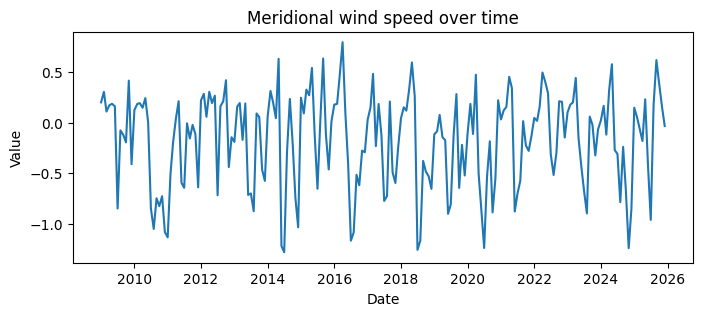

In [14]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["Meridional wind speed"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Meridional wind speed over time")
plt.show()

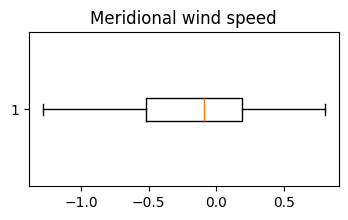

In [15]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["Meridional wind speed"].dropna(), vert=False)
plt.title("Meridional wind speed")
plt.show()

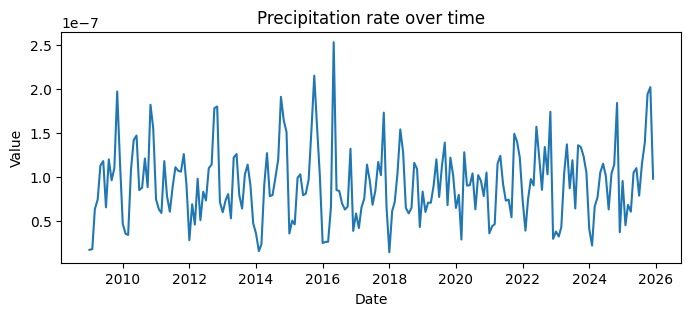

In [16]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["Precipitation rate"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Precipitation rate over time")
plt.show()

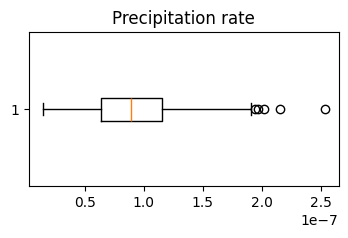

In [17]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["Precipitation rate"].dropna(), vert=False)
plt.title("Precipitation rate")
plt.show()

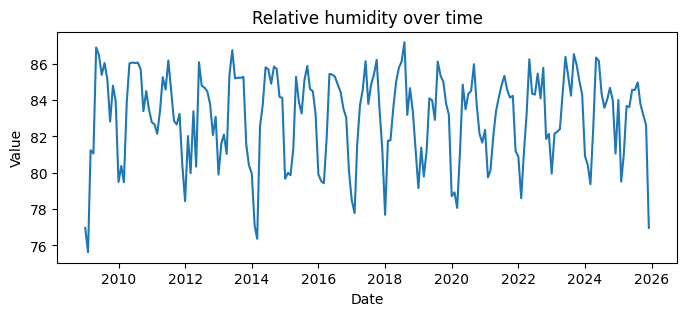

In [18]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["Relative humidity"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Relative humidity over time")
plt.show()

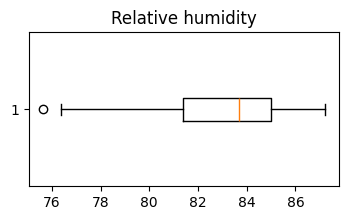

In [19]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["Relative humidity"].dropna(), vert=False)
plt.title("Relative humidity")
plt.show()

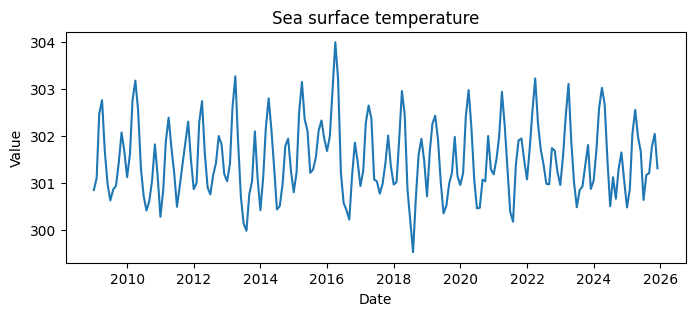

In [20]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["Sea surface temperature"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Sea surface temperature")
plt.show()

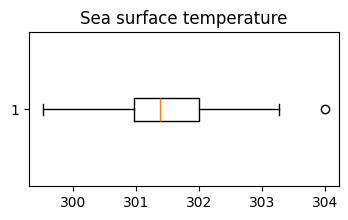

In [21]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["Sea surface temperature"].dropna(), vert=False)
plt.title("Sea surface temperature")
plt.show()

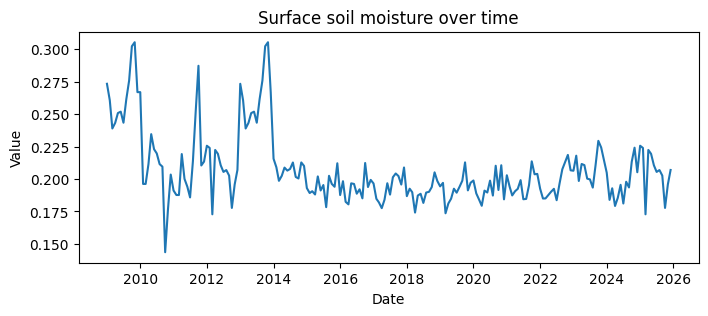

In [22]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["Surface soil moisture"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Surface soil moisture over time")
plt.show()

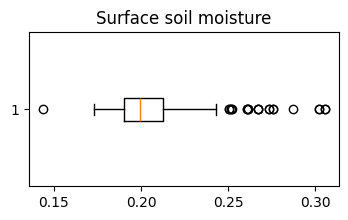

In [23]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["Surface soil moisture"].dropna(), vert=False)
plt.title("Surface soil moisture")
plt.show()

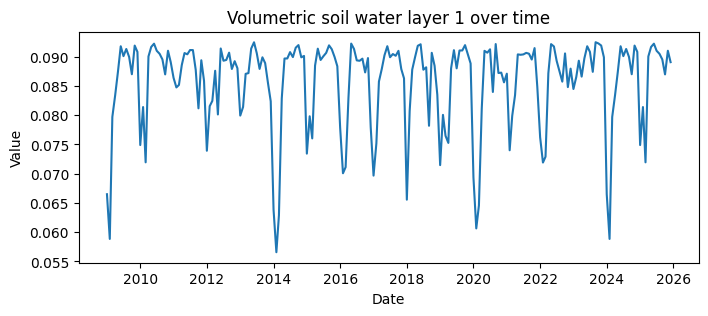

In [24]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["Volumetric soil water layer 1"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Volumetric soil water layer 1 over time")
plt.show()

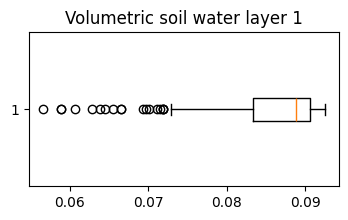

In [25]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["Volumetric soil water layer 1"].dropna(), vert=False)
plt.title("Volumetric soil water layer 1")
plt.show()

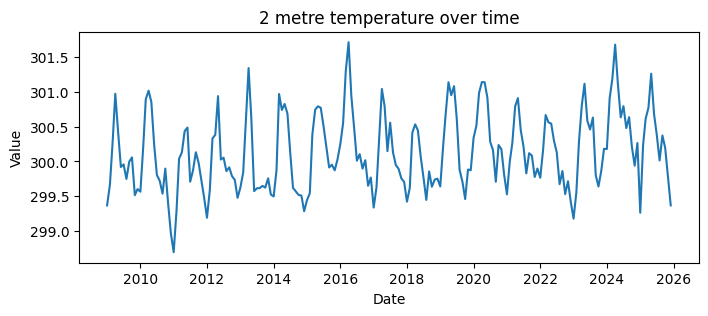

In [26]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["2 metre temperature"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("2 metre temperature over time")
plt.show()

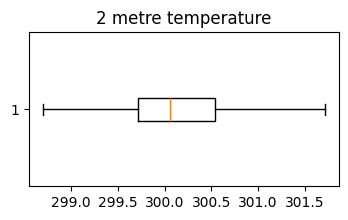

In [27]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["2 metre temperature"].dropna(), vert=False)
plt.title("2 metre temperature")
plt.show()

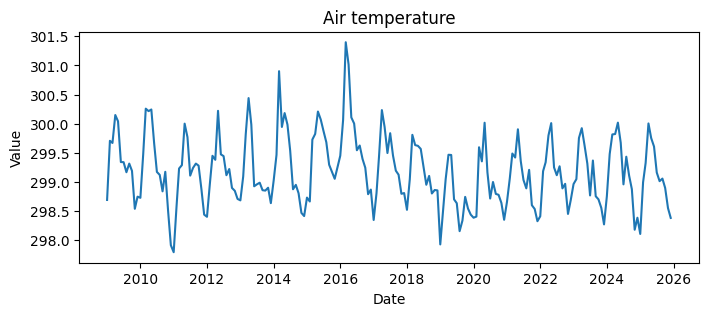

In [28]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["Air temperature"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Air temperature")
plt.show()

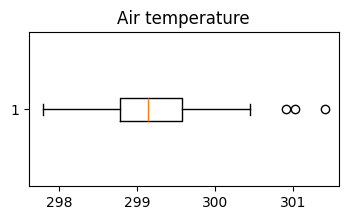

In [29]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["Air temperature"].dropna(), vert=False)
plt.title("Air temperature")
plt.show()

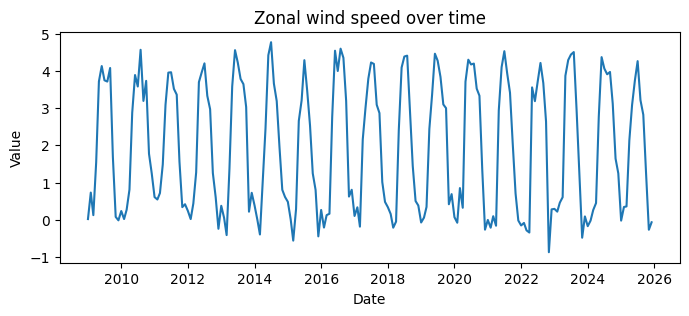

In [30]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["Zonal wind speed"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Zonal wind speed over time")
plt.show()

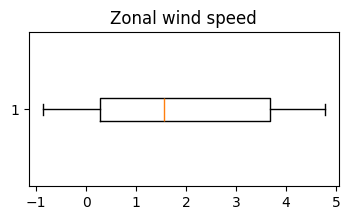

In [31]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["Zonal wind speed"].dropna(), vert=False)
plt.title("Zonal wind speed")
plt.show()

temporal scale mismatch

#run - pre process events

In [32]:
raw_df = pd.read_excel('/content/drive/My Drive/research-dataset/events.xlsx')
print(raw_df)

                  Period      Label
0   4/1/2010 - 3/31/2011    erosion
1   4/1/2011 - 3/31/2012     stable
2   4/1/2012 - 3/31/2013    erosion
3   4/1/2013 - 3/31/2014  accretion
4   4/1/2014 - 3/31/2015  accretion
5   4/1/2015 - 3/31/2016  accretion
6   4/1/2016 - 3/31/2017     stable
7   4/1/2017 - 3/31/2018    erosion
8   4/1/2018 - 3/31/2019     stable
9   4/1/2019 - 3/31/2020  accretion
10  4/1/2020 - 3/31/2021    erosion
11  4/1/2021 - 3/31/2022  accretion
12  4/1/2022 - 3/31/2023    erosion
13  4/1/2023 - 3/31/2024  accretion
14  4/1/2024 - 3/31/2025    erosion


In [33]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Period  15 non-null     object
 1   Label   15 non-null     object
dtypes: object(2)
memory usage: 372.0+ bytes


#run - hmm model and detect thresholds (env variables + events)

In [34]:
raw_df[['start_date', 'end_date']] = raw_df['Period'].str.split(' - ', expand=True)

raw_df['start_date'] = pd.to_datetime(raw_df['start_date'])
raw_df['end_date'] = pd.to_datetime(raw_df['end_date'])

data = raw_df.sort_values('start_date').reset_index(drop=True)

data.head()

,Period,Label,start_date,end_date
0,4/1/2010 - 3/31/2011,erosion,2010-04-01,2011-03-31
1,4/1/2011 - 3/31/2012,stable,2011-04-01,2012-03-31
2,4/1/2012 - 3/31/2013,erosion,2012-04-01,2013-03-31
3,4/1/2013 - 3/31/2014,accretion,2013-04-01,2014-03-31
4,4/1/2014 - 3/31/2015,accretion,2014-04-01,2015-03-31


In [35]:
merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df = merged_df.sort_values('Date').reset_index(drop=True)

raw_df['start_date'] = pd.to_datetime(raw_df['start_date'])
raw_df['end_date'] = pd.to_datetime(raw_df['end_date'])

In [36]:
feature_cols = merged_df.columns.drop('Date')

cycle_sequences = []
cycle_labels = []
cycle_years = []

for _, row in raw_df.iterrows():
    mask = (
        (merged_df['Date'] >= row['start_date']) &
        (merged_df['Date'] <= row['end_date'])
    )
    cycle_data = merged_df.loc[mask, feature_cols]

    if len(cycle_data) == 12:
        cycle_sequences.append(cycle_data.values)
        cycle_labels.append(row['Label'])
        cycle_years.append(row['start_date'].year)

In [37]:
print("Number of extracted cycles:", len(cycle_sequences))

cycle_lengths = [len(seq) for seq in cycle_sequences]
print("Cycle lengths:", cycle_lengths)

print("Unique cycle lengths:", set(cycle_lengths))

print("Label distribution:")
pd.Series(cycle_labels).value_counts()

Number of extracted cycles: 15
Cycle lengths: [12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12]
Unique cycle lengths: {12}
Label distribution:


,count
erosion,6
accretion,6
stable,3


In [38]:
scaler = StandardScaler()

X_concat = np.vstack(cycle_sequences)
X_scaled = scaler.fit_transform(X_concat)

lengths = [12] * len(cycle_sequences)

In [39]:
pd.DataFrame(X_concat).describe().T

,count,mean,std,min,25%,50%,75%,max
0,180.0,-1.913734e-01,4.681242e-01,-1.283917e+00,-5.423286e-01,-1.163508e-01,1.804223e-01,7.986807e-01
1,180.0,9.140944e-08,4.082767e-08,1.450000e-08,6.465000e-08,8.795000e-08,1.150000e-07,2.530000e-07
2,180.0,8.317655e+01,2.327945e+00,7.636336e+01,8.155965e+01,8.373842e+01,8.499305e+01,8.719093e+01
3,180.0,3.014893e+02,7.873799e-01,2.995190e+02,3.009627e+02,3.013540e+02,3.019915e+02,3.039885e+02
4,180.0,2.032215e-01,2.300185e-02,1.436273e-01,1.893991e-01,1.983929e-01,2.107216e-01,3.053039e-01
5,180.0,8.565864e-02,7.522130e-03,5.657974e-02,8.341497e-02,8.851349e-02,9.061823e-02,9.246095e-02
6,180.0,3.001328e+02,5.527298e-01,2.986945e+02,2.997135e+02,3.000576e+02,3.005425e+02,3.017132e+02
7,180.0,2.991789e+02,6.003528e-01,2.977935e+02,2.987766e+02,2.991159e+02,2.995377e+02,3.013993e+02
8,180.0,1.938673e+00,1.732734e+00,-8.710449e-01,3.153225e-01,1.522337e+00,3.660609e+00,4.768369e+00


In [40]:
hmm = GaussianHMM(
    n_components=4,
    covariance_type='full',
    n_iter=500,
    random_state=42
)

hmm.fit(X_scaled, lengths)

GaussianHMM(covariance_type='full', n_components=4, n_iter=500, random_state=42)

In [41]:
hidden_states = hmm.predict(X_scaled, lengths)

state_sequences = np.split(hidden_states, np.cumsum(lengths)[:-1])

In [42]:
state_label_map = {}

for state in range(hmm.n_components):
    labels = []
    for seq, lbl in zip(state_sequences, cycle_labels):
        if state in seq:
            labels.append(lbl)
    state_label_map[state] = pd.Series(labels).value_counts(normalize=True)

state_label_map

{0: erosion      0.428571
 accretion    0.357143
 stable       0.214286
 Name: proportion, dtype: float64,
 1: erosion      0.4
 accretion    0.4
 stable       0.2
 Name: proportion, dtype: float64,
 2: erosion      0.4
 accretion    0.4
 stable       0.2
 Name: proportion, dtype: float64,
 3: accretion    0.461538
 erosion      0.307692
 stable       0.230769
 Name: proportion, dtype: float64}

In [43]:
erosion_state = max(
    state_label_map,
    key=lambda s: state_label_map[s].get('erosion', 0)
)

print("Erosion-dominant hidden state:", erosion_state)

Erosion-dominant hidden state: 0


In [44]:
current_start = pd.Timestamp("2025-04-01")

current_mask = merged_df['Date'] >= current_start
current_cycle = merged_df.loc[current_mask, feature_cols]

current_scaled = scaler.transform(current_cycle.values)

current_states = hmm.predict(current_scaled)

print("Observed states so far:", current_states)

Observed states so far: [2 0 0 0 0 0 2 1 3]


In [45]:
last_state = current_states[-1]

transition_probs = hmm.transmat_[last_state]

erosion_transition_prob = transition_probs[erosion_state]

print("Probability of entering erosion regime next month:",
      erosion_transition_prob)

Probability of entering erosion regime next month: 0.0


In [46]:
threshold_scaled = hmm.means_[erosion_state]

threshold_real = scaler.inverse_transform(
    threshold_scaled.reshape(1, -1)
)

threshold_df = pd.DataFrame(
    threshold_real,
    columns=feature_cols,
    index=["Next_Month_Erosion_Threshold"]
)

threshold_df

,Meridional wind speed,Precipitation rate,Relative humidity,Sea surface temperature,Surface soil moisture,Volumetric soil water layer 1,2 metre temperature,Air temperature,Zonal wind speed
Next_Month_Erosion_Threshold,-0.351298,9.826722e-08,85.002092,301.084361,0.197075,0.090432,300.26869,299.344923,3.770575


In [47]:
latest_values = current_cycle.iloc[-1]

comparison = pd.DataFrame({
    'Current_Value': latest_values,
    'Threshold_Value': threshold_df.iloc[0],
    'Gap': threshold_df.iloc[0] - latest_values
})

comparison

,Current_Value,Threshold_Value,Gap
Meridional wind speed,-3.291529e-02,-3.512980e-01,-3.183828e-01
Precipitation rate,9.800000e-08,9.826722e-08,2.672161e-10
Relative humidity,7.696443e+01,8.500209e+01,8.037662e+00
Sea surface temperature,3.013060e+02,3.010844e+02,-2.216088e-01
Surface soil moisture,2.069449e-01,1.970750e-01,-9.869832e-03
Volumetric soil water layer 1,8.905468e-02,9.043211e-02,1.377425e-03
2 metre temperature,2.993681e+02,3.002687e+02,9.005899e-01
Air temperature,2.983825e+02,2.993449e+02,9.624229e-01
Zonal wind speed,-6.690580e-02,3.770575e+00,3.837480e+00


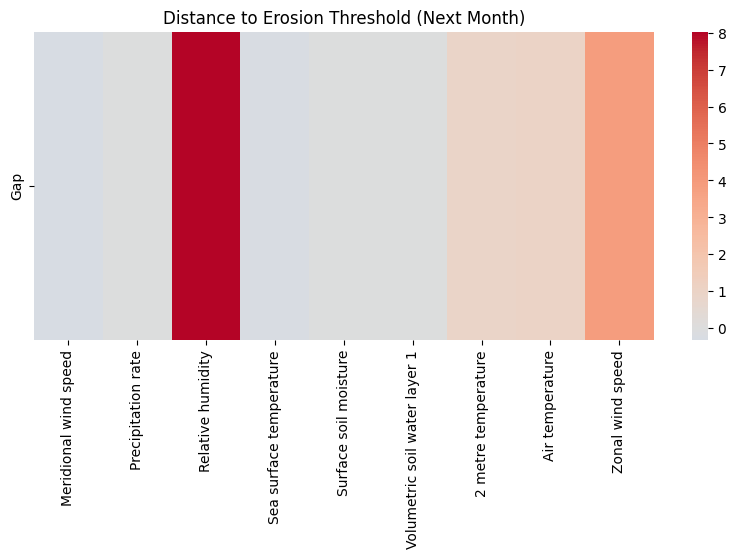

In [48]:
plt.figure(figsize=(10,4))
sns.heatmap(comparison[['Gap']].T, cmap='coolwarm', center=0)
plt.title("Distance to Erosion Threshold (Next Month)")
plt.show()

Regime stability check

In [49]:
switch_counts = []

for seq in state_sequences:
    switches = np.sum(seq[1:] != seq[:-1])
    switch_counts.append(switches)

pd.Series(switch_counts).describe()

,0
count,15.000000
mean,4.533333
std,1.125463
min,2.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,6.000000


Transition matrix sanity

In [50]:
pd.DataFrame(
    hmm.transmat_,
    columns=[f"S{i}" for i in range(hmm.n_components)],
    index=[f"S{i}" for i in range(hmm.n_components)]
)

,S0,S1,S2,S3
S0,7.557389e-01,8.775063e-14,0.244261,0.000000
S1,1.388819e-320,6.159183e-01,0.029681,0.354401
S2,3.359526e-01,3.356130e-01,0.306017,0.022418
S3,0.000000e+00,1.110357e-01,0.249768,0.639197


Shuffle test

In [51]:
X_shuffled = X_scaled.copy()
np.random.shuffle(X_shuffled)

hmm_shuffled = GaussianHMM(
    n_components=4,
    covariance_type="full",
    n_iter=300,
    random_state=42
)

hmm_shuffled.fit(X_shuffled, lengths)

GaussianHMM(covariance_type='full', n_components=4, n_iter=300, random_state=42)

Regime-wise variable profiles

In [52]:
state_means = pd.DataFrame(
    hmm.means_,
    columns=feature_cols,
    index=[f"State_{i}" for i in range(hmm.n_components)]
)

state_means

,Meridional wind speed,Precipitation rate,Relative humidity,Sea surface temperature,Surface soil moisture,Volumetric soil water layer 1,2 metre temperature,Air temperature,Zonal wind speed
State_0,-0.342582,0.168437,0.786375,-0.515719,-0.267961,0.636359,0.246583,0.277373,1.060181
State_1,-0.290801,0.234729,-0.273946,0.187442,0.284869,0.192584,-0.760500,-0.716725,-0.870154
State_2,0.262301,0.201821,0.062231,0.648340,0.204424,0.000422,0.469193,0.415415,0.006041
State_3,0.653532,-1.025304,-1.412795,-0.295599,-0.170708,-1.607904,-0.334108,-0.363257,-1.099957


Seasonal alignment test

In [53]:
state_months = []

for year, seq in zip(cycle_years, state_sequences):
    months = pd.date_range(
        start=f"{year}-04-01", periods=12, freq="MS"
    ).month
    state_months.extend(zip(months, seq))

state_month_df = pd.DataFrame(state_months, columns=["Month", "State"])
pd.crosstab(state_month_df["Month"], state_month_df["State"])

State,0,1,2,3
Month,,,,
1,0,3,0,12
2,0,3,0,12
3,0,5,6,4
4,0,0,15,0
5,10,0,5,0
6,14,0,1,0
7,14,0,1,0
8,12,0,3,0
9,11,0,4,0


Final-state dominance test

In [54]:
final_states = [
    seq[-1] for seq, lbl in zip(state_sequences, cycle_labels)
    if lbl == "erosion"
]

pd.Series(final_states).value_counts(normalize=True)

,proportion
1,0.500000
3,0.333333
2,0.166667


#run - build cvi using evaluation, check cvi for present

In [55]:
pd.set_option("display.expand_frame_repr", False)

df = pd.read_excel('/content/drive/My Drive/research-dataset/evaluation.xlsx')

main_df = df[[
    "Date",
    "Elevation Min m",
    "Elevation Max m",
    "Elevation AVG m",
    "Distance meters",
    "Elevation Gain m",
    "Elevation Loss m",
    "AVG Slope steepest upward (%)",
    "AVG Slope steepest downward (%)"
]].copy()

main_df.head()

,Date,Elevation Min m,Elevation Max m,Elevation AVG m,Distance meters,Elevation Gain m,Elevation Loss m,AVG Slope steepest upward (%),AVG Slope steepest downward (%)
0,2025-07-30,0.0,14.63,6.40,1351.85,65.23,-55.17,8.0,-6.7
1,2025-02-28,0.0,14.33,6.40,1367.94,64.92,-54.25,7.5,-6.9
2,2024-02-29,0.0,21.03,4.57,1367.94,61.57,-49.68,7.1,-6.2
3,2023-04-30,0.3,11.89,5.79,1367.94,68.28,-56.99,7.8,-7.2
4,2023-02-28,0.0,15.85,6.10,1367.94,71.93,-60.35,8.9,-7.9


In [56]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Date                             32 non-null     datetime64[ns]
 1   Elevation Min m                  32 non-null     float64       
 2   Elevation Max m                  32 non-null     float64       
 3   Elevation AVG m                  32 non-null     float64       
 4   Distance meters                  32 non-null     float64       
 5   Elevation Gain m                 32 non-null     float64       
 6   Elevation Loss m                 32 non-null     float64       
 7   AVG Slope steepest upward (%)    32 non-null     float64       
 8   AVG Slope steepest downward (%)  32 non-null     float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 2.4 KB


In [57]:
main_df.drop(columns=["Date"]).describe()

,Elevation Min m,Elevation Max m,Elevation AVG m,Distance meters,Elevation Gain m,Elevation Loss m,AVG Slope steepest upward (%),AVG Slope steepest downward (%)
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,0.009375,13.554375,5.410937,1364.923750,65.169375,-54.177500,7.665625,-6.950000
std,0.053033,1.986628,1.021398,8.610564,4.690690,4.862977,0.690306,0.622689
min,0.000000,11.580000,3.050000,1351.850000,55.470000,-61.260000,6.400000,-8.000000
25%,0.000000,11.812500,4.570000,1363.917500,62.560000,-57.837500,7.175000,-7.325000
50%,0.000000,13.410000,5.790000,1367.940000,65.075000,-54.555000,7.650000,-6.950000
75%,0.000000,14.330000,6.175000,1367.940000,68.655000,-51.590000,8.200000,-6.500000
max,0.300000,21.030000,7.010000,1384.040000,72.240000,-43.590000,8.900000,-5.500000


In [58]:
main_df = main_df.copy()

main_df.loc[:, 'Date'] = pd.to_datetime(main_df['Date'])
main_df.loc[:, 'Year'] = main_df['Date'].dt.year

annual_df = (
    main_df.groupby('Year')
    .agg({
        'Elevation Min m': 'mean',
        'Elevation Max m': 'mean',
        'Elevation AVG m': 'mean',
        'Distance meters': 'mean',
        'Elevation Gain m': 'mean',
        'Elevation Loss m': 'mean',
        'AVG Slope steepest upward (%)': 'mean',
        'AVG Slope steepest downward (%)': 'mean'
    })
    .reset_index()
)

annual_df

,Year,Elevation Min m,Elevation Max m,Elevation AVG m,Distance meters,Elevation Gain m,Elevation Loss m,AVG Slope steepest upward (%),AVG Slope steepest downward (%)
0,2010,0.00,14.6300,6.022500,1355.8725,67.5875,-57.835000,8.200000,-7.475000
1,2012,0.00,13.8700,6.400000,1359.8950,64.4650,-54.100000,7.200000,-7.000000
2,2013,0.00,14.3300,6.710000,1367.9400,62.7900,-51.820000,7.100000,-6.500000
3,2014,0.00,13.4100,6.100000,1367.9400,64.9200,-53.640000,7.500000,-6.700000
4,2015,0.00,11.7350,4.115000,1367.9400,57.4550,-46.025000,6.550000,-6.150000
5,2016,0.00,11.5800,3.660000,1367.9400,61.5700,-49.990000,7.600000,-6.400000
6,2017,0.00,12.0900,4.573333,1367.9400,64.7200,-53.443333,7.533333,-6.866667
7,2018,0.00,11.5800,4.570000,1351.8500,72.2400,-60.960000,8.700000,-7.800000
8,2019,0.00,12.7400,5.242000,1371.1600,65.7740,-54.314000,7.640000,-6.980000
9,2020,0.00,12.8775,4.877500,1371.9650,62.4825,-50.672500,7.325000,-6.500000


In [59]:
df = annual_df.copy()

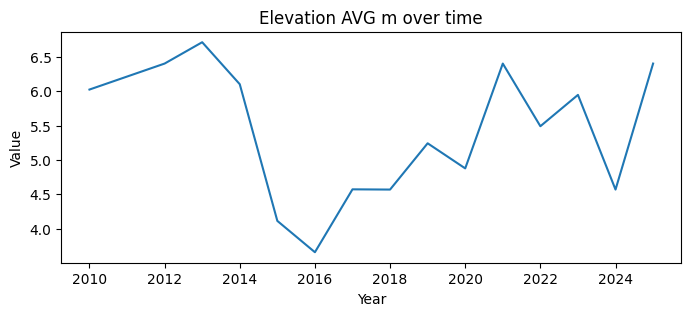

In [60]:
plt.figure(figsize=(8, 3))
plt.plot(df["Year"], df["Elevation AVG m"])
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Elevation AVG m over time")
plt.show()

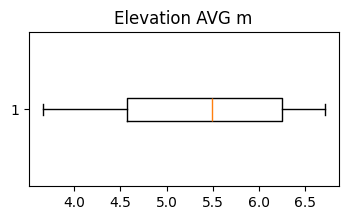

In [61]:
plt.figure(figsize=(4, 2))
plt.boxplot(df["Elevation AVG m"].dropna(), vert=False)
plt.title("Elevation AVG m")
plt.show()

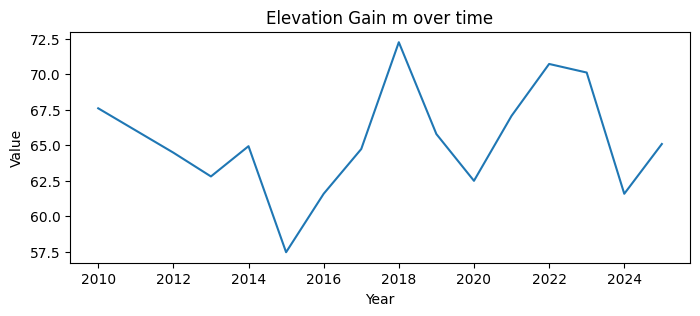

In [62]:
plt.figure(figsize=(8, 3))
plt.plot(df["Year"], df["Elevation Gain m"])
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Elevation Gain m over time")
plt.show()

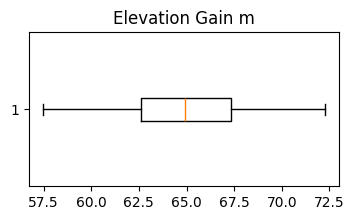

In [63]:
plt.figure(figsize=(4, 2))
plt.boxplot(df["Elevation Gain m"].dropna(), vert=False)
plt.title("Elevation Gain m")
plt.show()

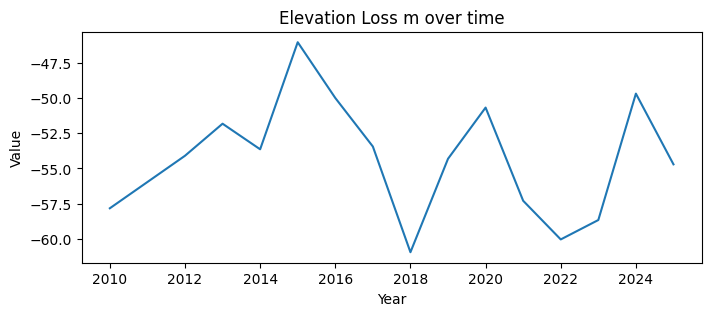

In [64]:
plt.figure(figsize=(8, 3))
plt.plot(df["Year"], df["Elevation Loss m"])
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Elevation Loss m over time")
plt.show()

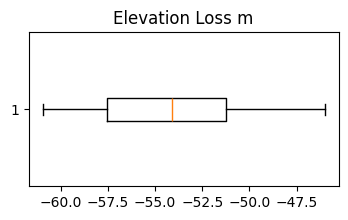

In [65]:
plt.figure(figsize=(4, 2))
plt.boxplot(df["Elevation Loss m"].dropna(), vert=False)
plt.title("Elevation Loss m")
plt.show()

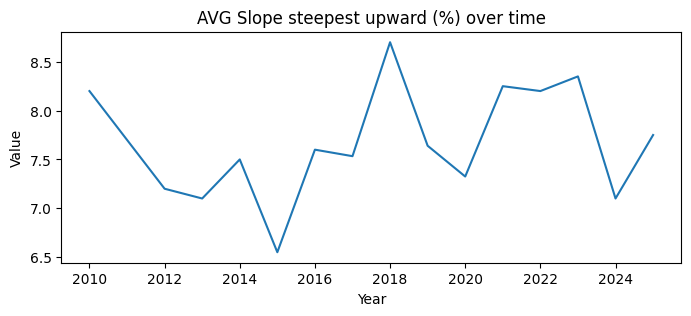

In [66]:
plt.figure(figsize=(8, 3))
plt.plot(df["Year"], df["AVG Slope steepest upward (%)"])
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("AVG Slope steepest upward (%) over time")
plt.show()

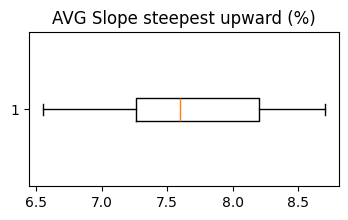

In [67]:
plt.figure(figsize=(4, 2))
plt.boxplot(df["AVG Slope steepest upward (%)"].dropna(), vert=False)
plt.title("AVG Slope steepest upward (%)")
plt.show()

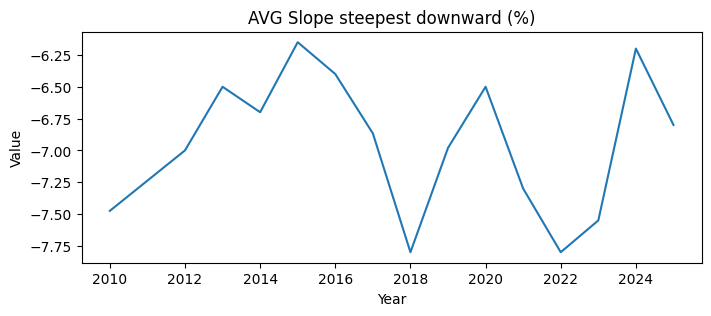

In [68]:
plt.figure(figsize=(8, 3))
plt.plot(df["Year"], df["AVG Slope steepest downward (%)"])
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("AVG Slope steepest downward (%)")
plt.show()

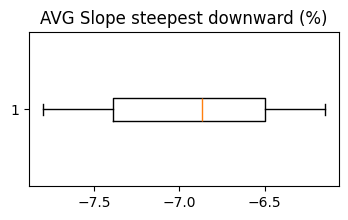

In [69]:
plt.figure(figsize=(4, 2))
plt.boxplot(df["AVG Slope steepest downward (%)"].dropna(), vert=False)
plt.title("AVG Slope steepest downward (%)")
plt.show()

In [70]:
df["Elevation AVG m"].quantile([0, 0.25, 0.5, 0.75, 1.0])

,Elevation AVG m
0.00,3.660000
0.25,4.571667
0.50,5.490000
0.75,6.250000
1.00,6.710000


In [71]:
elev_avg = df["Elevation AVG m"].quantile([0, 0.25, 0.5, 0.75, 1])

elev_avg_min = elev_avg.loc[0.0]
elev_avg_max = elev_avg.loc[1.0]

In [72]:
def Elevation_AVG_m(value, series):
    q25, q50, q75 = series.quantile([0.25, 0.5, 0.75])

    if value <= q25:
        return 4
    elif value <= q50:
        return 3
    elif value <= q75:
        return 2
    else:
        return 1

In [73]:
df["Elevation Gain m"].quantile([0, 0.25, 0.5, 0.75, 1.0])

,Elevation Gain m
0.00,57.45500
0.25,62.63625
0.50,64.92000
0.75,67.32125
1.00,72.24000


In [74]:
elev_gain = df["Elevation Gain m"].quantile([0, 0.25, 0.5, 0.75, 1])

elev_gain_min = elev_gain.loc[0.0]
elev_gain_max = elev_gain.loc[1.0]

In [75]:
def Elevation_Gain_m(value, series):
    q25, q50, q75 = series.quantile([0.25, 0.5, 0.75])

    if value <= q25:
        return 4
    elif value <= q50:
        return 3
    elif value <= q75:
        return 2
    else:
        return 1

In [76]:
df["Elevation Loss m"].quantile([0, 0.25, 0.5, 0.75, 1.0])

,Elevation Loss m
0.00,-60.96000
0.25,-57.56750
0.50,-54.10000
0.75,-51.24625
1.00,-46.02500


In [77]:
elev_loss = df["Elevation Loss m"].quantile([0, 0.25, 0.5, 0.75, 1])

elev_loss_min = elev_loss.loc[0.0]
elev_loss_max = elev_loss.loc[1.0]

In [78]:
def Elevation_Loss_m(value, series):
    q25, q50, q75 = series.quantile([0.25, 0.5, 0.75])

    if value <= q25:
        return 4
    elif value <= q50:
        return 3
    elif value <= q75:
        return 2
    else:
        return 1

In [79]:
df["AVG Slope steepest upward (%)"].quantile([0, 0.25, 0.5, 0.75, 1.0])

,AVG Slope steepest upward (%)
0.00,6.5500
0.25,7.2625
0.50,7.6000
0.75,8.2000
1.00,8.7000


In [80]:
slope_up = df["AVG Slope steepest upward (%)"].quantile([0, 0.25, 0.5, 0.75, 1])

slope_up_min = slope_up.loc[0.0]
slope_up_max = slope_up.loc[1.0]

In [81]:
def AVG_Slope_steepest_upward(value, series):
    q25, q50, q75 = series.quantile([0.25, 0.5, 0.75])

    if value <= q25:
        return 4
    elif value <= q50:
        return 3
    elif value <= q75:
        return 2
    else:
        return 1

In [82]:
df["AVG Slope steepest downward (%)"].quantile([0, 0.25, 0.5, 0.75, 1.0])

,AVG Slope steepest downward (%)
0.00,-7.800000
0.25,-7.387500
0.50,-6.866667
0.75,-6.500000
1.00,-6.150000


In [83]:
slope_down = df["AVG Slope steepest downward (%)"].quantile([0, 0.25, 0.5, 0.75, 1])

slope_down_min = slope_down.loc[0.0]
slope_down_max = slope_down.loc[1.0]

In [84]:
def AVG_Slope_steepest_downward(value, series):
    q25, q50, q75 = series.quantile([0.25, 0.5, 0.75])

    if value <= q25:
        return 4
    elif value <= q50:
        return 3
    elif value <= q75:
        return 2
    else:
        return 1

In [85]:
def CVI (value1, value2, value3, value4, value5):
  r_elev_avg  = Elevation_AVG_m(value1, df['Elevation AVG m'])
  r_elev_gain = Elevation_Gain_m(value2, df['Elevation Gain m'])
  r_elev_loss = Elevation_Loss_m(value3, df['Elevation Loss m'])
  r_slope_up = AVG_Slope_steepest_upward(value4, df['AVG Slope steepest upward (%)'])
  r_slope_down = AVG_Slope_steepest_downward(value5, df['AVG Slope steepest downward (%)'])

  ranks = np.array([
        r_elev_avg,
        r_elev_gain,
        r_elev_loss,
        r_slope_up,
        r_slope_down
    ])

  CVI = np.sqrt(ranks.prod() / len(ranks))
  return CVI

In [86]:
upper_bound = CVI(elev_avg_min,elev_gain_min,elev_loss_min,slope_up_min,slope_down_min)
print(upper_bound)

14.310835055998654


In [87]:
lower_bound = CVI(elev_avg_max,elev_gain_max,elev_loss_max,slope_up_max,slope_down_max)
print(lower_bound)

0.4472135954999579


In [88]:
def CVI_VULNERABILITY(value, upper_bound, lower_bound):
    interval = (upper_bound - lower_bound) / 4

    r1 = lower_bound + interval
    r2 = lower_bound + 2 * interval
    r3 = lower_bound + 3 * interval

    if value <= r1:
        print("Very low")
    elif value <= r2:
        print("Low")
    elif value <= r3:
        print("Moderate")
    else:
        print("High")

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             15 non-null     int32  
 1   Elevation Min m                  15 non-null     float64
 2   Elevation Max m                  15 non-null     float64
 3   Elevation AVG m                  15 non-null     float64
 4   Distance meters                  15 non-null     float64
 5   Elevation Gain m                 15 non-null     float64
 6   Elevation Loss m                 15 non-null     float64
 7   AVG Slope steepest upward (%)    15 non-null     float64
 8   AVG Slope steepest downward (%)  15 non-null     float64
dtypes: float64(8), int32(1)
memory usage: 1.1 KB


In [90]:
latest_row = df.loc[df["Year"].idxmax()]
print(latest_row)

Year                               2025.000
Elevation Min m                       0.000
Elevation Max m                      14.480
Elevation AVG m                       6.400
Distance meters                    1359.895
Elevation Gain m                     65.075
Elevation Loss m                    -54.710
AVG Slope steepest upward (%)         7.750
AVG Slope steepest downward (%)      -6.800
Name: 14, dtype: float64


In [91]:
value1 = latest_row["Elevation AVG m"]
value2 = latest_row["Elevation Gain m"]
value3 = latest_row["Elevation Loss m"]
value4 = latest_row["AVG Slope steepest upward (%)"]
value5 = latest_row["AVG Slope steepest downward (%)"]

CVI_VULNERABILITY(CVI(value1, value2, value3, value4, value5),upper_bound,lower_bound)

Very low


#run - forecast evaluation, check cvi for forecast

In [92]:
source_df = annual_df.copy()

cvi_columns = [
    "Year",
    "Elevation AVG m",
    "Elevation Gain m",
    "Elevation Loss m",
    "AVG Slope steepest upward (%)",
    "AVG Slope steepest downward (%)"
]

source_df = source_df[cvi_columns]

In [93]:
source_df

,Year,Elevation AVG m,Elevation Gain m,Elevation Loss m,AVG Slope steepest upward (%),AVG Slope steepest downward (%)
0,2010,6.022500,67.5875,-57.835000,8.200000,-7.475000
1,2012,6.400000,64.4650,-54.100000,7.200000,-7.000000
2,2013,6.710000,62.7900,-51.820000,7.100000,-6.500000
3,2014,6.100000,64.9200,-53.640000,7.500000,-6.700000
4,2015,4.115000,57.4550,-46.025000,6.550000,-6.150000
5,2016,3.660000,61.5700,-49.990000,7.600000,-6.400000
6,2017,4.573333,64.7200,-53.443333,7.533333,-6.866667
7,2018,4.570000,72.2400,-60.960000,8.700000,-7.800000
8,2019,5.242000,65.7740,-54.314000,7.640000,-6.980000
9,2020,4.877500,62.4825,-50.672500,7.325000,-6.500000


In [94]:
source_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             15 non-null     int32  
 1   Elevation AVG m                  15 non-null     float64
 2   Elevation Gain m                 15 non-null     float64
 3   Elevation Loss m                 15 non-null     float64
 4   AVG Slope steepest upward (%)    15 non-null     float64
 5   AVG Slope steepest downward (%)  15 non-null     float64
dtypes: float64(5), int32(1)
memory usage: 792.0 bytes


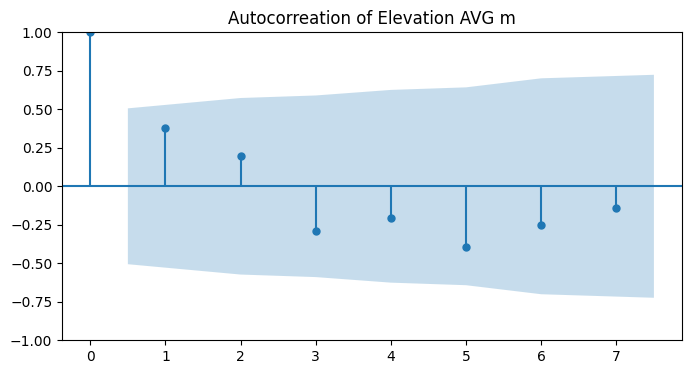

In [95]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(source_df["Elevation AVG m"], ax=ax)
plt.title("Autocorreation of Elevation AVG m")
plt.show()

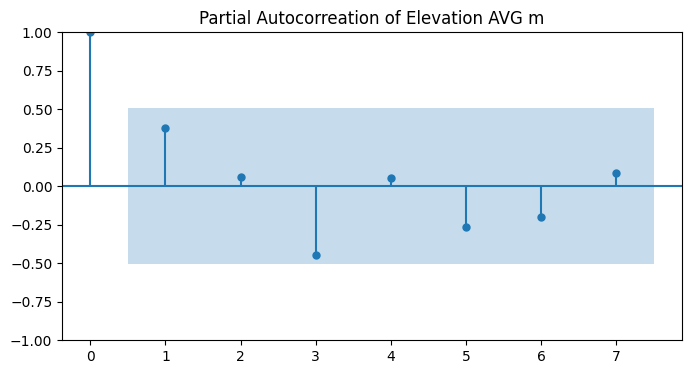

In [96]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_pacf(source_df["Elevation AVG m"], ax=ax)
plt.title("Partial Autocorreation of Elevation AVG m")
plt.show()

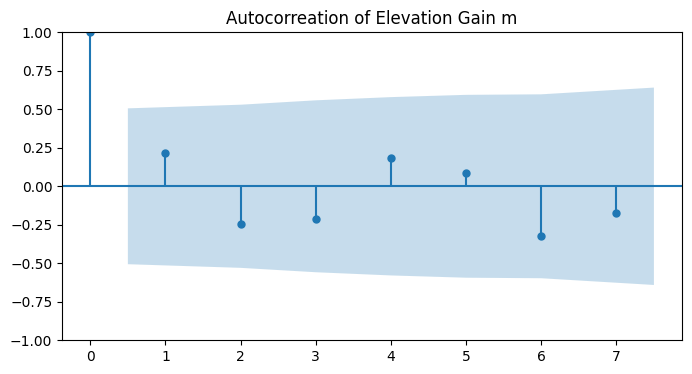

In [97]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(source_df["Elevation Gain m"], ax=ax)
plt.title("Autocorreation of Elevation Gain m")
plt.show()

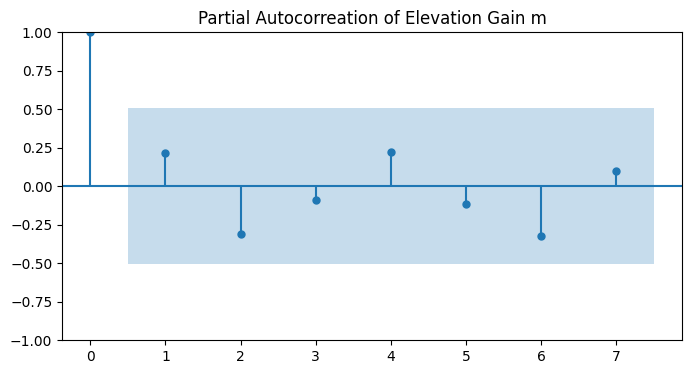

In [98]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_pacf(source_df["Elevation Gain m"], ax=ax)
plt.title("Partial Autocorreation of Elevation Gain m")
plt.show()

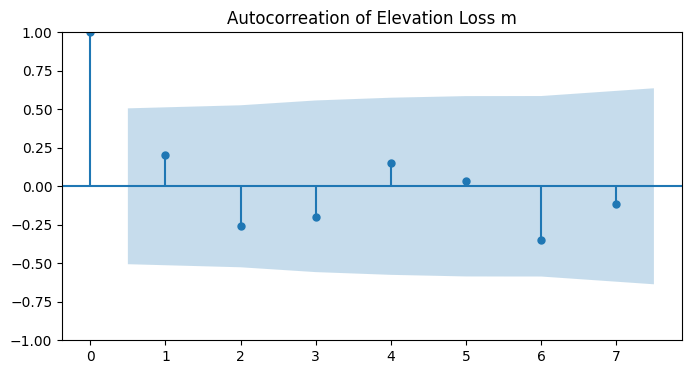

In [99]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(source_df["Elevation Loss m"], ax=ax)
plt.title("Autocorreation of Elevation Loss m")
plt.show()

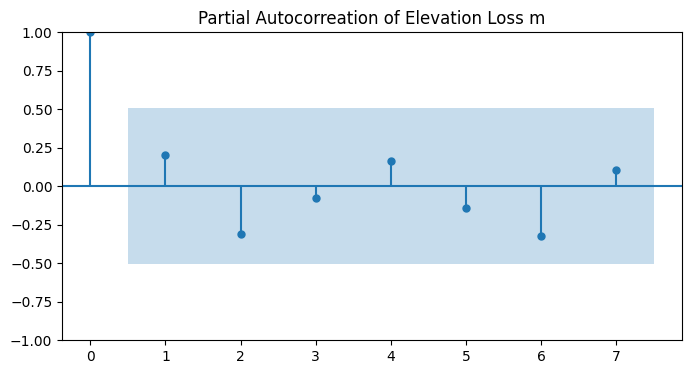

In [100]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_pacf(source_df["Elevation Loss m"], ax=ax)
plt.title("Partial Autocorreation of Elevation Loss m")
plt.show()

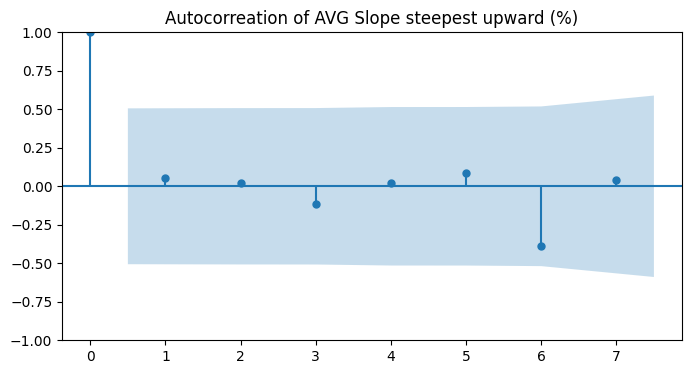

In [101]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(source_df["AVG Slope steepest upward (%)"], ax=ax)
plt.title("Autocorreation of AVG Slope steepest upward (%)")
plt.show()

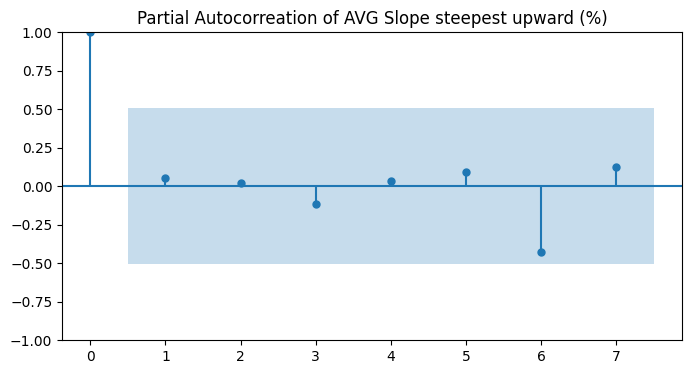

In [102]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_pacf(source_df["AVG Slope steepest upward (%)"], ax=ax)
plt.title("Partial Autocorreation of AVG Slope steepest upward (%)")
plt.show()

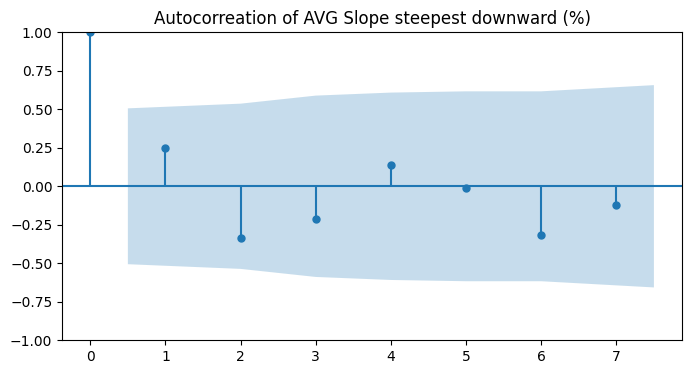

In [103]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(source_df["AVG Slope steepest downward (%)"], ax=ax)
plt.title("Autocorreation of AVG Slope steepest downward (%)")
plt.show()

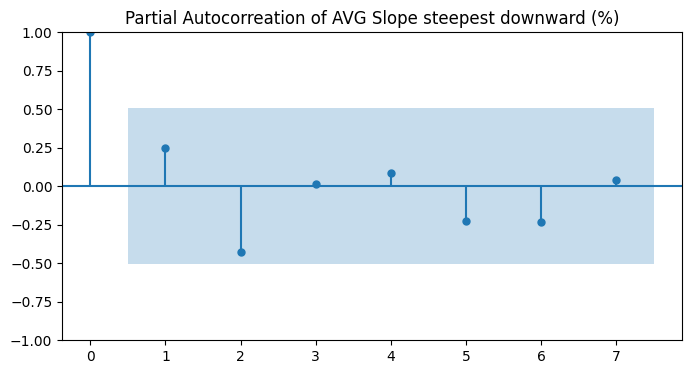

In [104]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_pacf(source_df["AVG Slope steepest downward (%)"], ax=ax)
plt.title("Partial Autocorreation of AVG Slope steepest downward (%)")
plt.show()

In [105]:
source_df = source_df.sort_values("Year")
source_df = source_df.set_index("Year")

source_df.index = pd.to_datetime(source_df.index, format="%Y")

In [106]:
adf_results = []

for col in source_df.select_dtypes(include="number").columns:
    result = adfuller(source_df[col].dropna())

    adf_results.append({
        "Variable": col,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Lags Used": result[2],
        "Observations": result[3],
        "Stationary (p<0.05)": result[1] < 0.05
    })

adf_df = pd.DataFrame(adf_results)
adf_df

,Variable,ADF Statistic,p-value,Lags Used,Observations,Stationary (p<0.05)
0,Elevation AVG m,-2.537748,0.106558,5,9,False
1,Elevation Gain m,-4.442732,0.000249,5,9,True
2,Elevation Loss m,-3.419009,0.010328,5,9,True
3,AVG Slope steepest upward (%),-4.182456,0.000705,5,9,True
4,AVG Slope steepest downward (%),-2.396770,0.142650,5,9,False


In [107]:
non_stationary_vars = adf_df.loc[
    adf_df["Stationary (p<0.05)"] == False, "Variable"
].tolist()

non_stationary_vars

['Elevation AVG m', 'AVG Slope steepest downward (%)']

In [108]:
df_diff = source_df.copy()

for col in non_stationary_vars:
    df_diff[col] = df_diff[col].diff()

In [109]:
adf_results_stationary = []

for col in df_diff.select_dtypes(include="number").columns:
    result = adfuller(df_diff[col].dropna())

    adf_results_stationary.append({
          "Variable": col,
          "ADF Statistic": result[0],
          "p-value": result[1],
          "Lags Used": result[2],
          "Observations": result[3],
          "Stationary (p<0.05)": result[1] < 0.05
      })

adf_df = pd.DataFrame(adf_results_stationary)
adf_df

,Variable,ADF Statistic,p-value,Lags Used,Observations,Stationary (p<0.05)
0,Elevation AVG m,-1.899556,0.332270,5,8,False
1,Elevation Gain m,-4.442732,0.000249,5,9,True
2,Elevation Loss m,-3.419009,0.010328,5,9,True
3,AVG Slope steepest upward (%),-4.182456,0.000705,5,9,True
4,AVG Slope steepest downward (%),-3.416003,0.010425,2,11,True


VECM

In [110]:
from statsmodels.tsa.vector_ar.vecm import (
    coint_johansen,
    VECM
)

In [111]:
vecm_df = source_df.copy()

In [112]:
johansen = coint_johansen(vecm_df, det_order=0, k_ar_diff=1)

trace_stat = johansen.lr1
crit_95 = johansen.cvt[:, 1]

rank = sum(trace_stat > crit_95)
rank

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/vector_ar/vecm.py:730: RuntimeWarning: invalid value encountered in log
  tmp = np.log(iota - a)[i:]
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/vector_ar/vecm.py:732: RuntimeWarning: invalid value encountered in log
  lr2[i] = -t * np.log(1 - a[i])


np.int64(1)

In [113]:
vecm_model = VECM(
    vecm_df.astype(float),
    k_ar_diff=0,
    coint_rank=rank,
    deterministic="co"
)

vecm_res = vecm_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [114]:
vecm_forecast = vecm_res.predict(steps=1)

vecm_forecast = np.real(vecm_forecast)

vecm_2026 = pd.DataFrame(
    vecm_forecast,
    columns=vecm_df.columns,
    index=[2026]
)

vecm_2026

,Elevation AVG m,Elevation Gain m,Elevation Loss m,AVG Slope steepest upward (%),AVG Slope steepest downward (%)
2026,6.499355,65.676542,-55.195332,7.321861,-7.001919


Multivariate Linear Trend

In [115]:
trend_df = source_df.copy()

t = np.arange(len(trend_df))

In [116]:
trend_forecast = {}

for col in trend_df.columns:
    model = LinearRegression()
    model.fit(t.reshape(-1, 1), trend_df[col].values)
    trend_forecast[col] = model.predict([[len(t)]])[0]

In [117]:
trend_2026 = pd.DataFrame(trend_forecast, index=[2026])
trend_2026

,Elevation AVG m,Elevation Gain m,Elevation Loss m,AVG Slope steepest upward (%),AVG Slope steepest downward (%)
2026,5.272341,66.847643,-55.572722,7.951032,-7.045873


metric

In [118]:
vecm_errors = []

for i in range(8, len(vecm_df) - 1):
    train = vecm_df.iloc[:i]

    model = VECM(
        train.astype(float),
        k_ar_diff=0,
        coint_rank=rank,
        deterministic="co"
    ).fit()

    pred = model.predict(steps=1)
    pred = np.real(pred)

    true = vecm_df.iloc[i:i+1].values
    vecm_errors.append(mean_squared_error(true, pred))

vecm_rmse = np.sqrt(np.mean(vecm_errors))
vecm_rmse

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


np.float64(3.250768486399278)

In [119]:
trend_errors = []

for i in range(8, len(trend_df) - 1):
    train = trend_df.iloc[:i]
    t_train = np.arange(len(train))

    preds = []
    for col in train.columns:
        lr = LinearRegression()
        lr.fit(t_train.reshape(-1, 1), train[col].values)
        preds.append(lr.predict([[len(train)]])[0])

    true = trend_df.iloc[i].values
    trend_errors.append(mean_squared_error(true, preds))

trend_rmse = np.sqrt(np.mean(trend_errors))
trend_rmse

np.float64(2.854487639210748)

In [120]:
if vecm_rmse < trend_rmse:
    print("Use VECM for final 2026 forecast")
else:
    print("Use Multivariate Linear Trend for final 2026 forecast")

Use Multivariate Linear Trend for final 2026 forecast


cvi for forecast

In [121]:
value1 = trend_df["Elevation AVG m"].iloc[0]
value2 = trend_df["Elevation Gain m"].iloc[0]
value3 = trend_df["Elevation Loss m"].iloc[0]
value4 = trend_df["AVG Slope steepest upward (%)"].iloc[0]
value5 = trend_df["AVG Slope steepest downward (%)"].iloc[0]

CVI_VULNERABILITY(CVI(value1, value2, value3, value4, value5),upper_bound,lower_bound)

Very low
